# Incremental Capstone Session 
**Course:** Applied Data Science with Python  
**Student Name:** `Brian Gaddy`  
**Date:** `05-08-2026`  

---

## 1. Objective

> Spotify wants to create cohorts of different songs to enhance song recommendations. The cohorts will be based on various related features to ensure each group contains similar types of songs. The objective is to perform exploratory data analysis and cluster analysis to create cohorts of songs. The goal is to better understand the various factors that create a cohort of songs. 

## 2. Data Overview

| Field | Details |
|---|---|
| **Source** | *(e.g., AusApparalSales4thQrt2020.csv)* |
| **Rows** | 1610 |
| **Columns** | 18 |
| **Date Range** | 4/16/64 - 6/10/22 |
| **Key Columns** | popularity, release_date, album, name |

## 3. Imports

In [2]:
# Import libraries and set the plot styling

# Preprocessing
import io
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np
from scipy import stats
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats.mstats import winsorize
from IPython.display import display
import math
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Supervised Learning
# CLUSTERING PIPELINE (K-Means, Hierarchical, DBSCAN, PCA, Profiling, Plotly)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as shc
import plotly.express as px

#Regression
from sklearn import model_selection
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold, cross_val_predict, KFold
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor

#Classification
from sklearn.preprocessing import label_binarize
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, classification_report, confusion_matrix, r2_score, mean_squared_error, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import itertools
from itertools import cycle
from sklearn.naive_bayes import MultinomialNB
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from imblearn.under_sampling import RandomUnderSampler
from imblearn.ensemble import BalancedRandomForestClassifier

# Ensemble Learning
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from vecstack import stacking

# Unserpervised Learning Dimensionality reduction
from sklearn.feature_selection import VarianceThreshold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from pyECLAT import ECLAT
from sklearn.metrics.pairwise import cosine_similarity
import statistics
import operator
import scipy.sparse as sp
from scipy.sparse.linalg import svds
import logging
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from joblib import Parallel, delayed

# Surprise library for matrix factorization-based recommendation algorithms
import surprise
from surprise import SVD, NMF, KNNBasic
from surprise import Dataset, Reader
from surprise.model_selection import cross_validate

# ============================================================
# GLOBAL PLOT STYLE FOR CONSISTENT DASHBOARD VISUALS
# ============================================================

# Set Seaborn theme
sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=1.1
)

# Global Matplotlib settings
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 1.2,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.autolayout": True,
    "axes.grid": True,
    "grid.color": "#DDDDDD",
    "grid.linestyle": "--",
    "grid.linewidth": 0.7
})

# Consistent color palettes
HEATMAP_CMAP = "Blues"
CONFUSION_CMAP = "Purples"
ROC_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
              "#9467bd", "#8c564b", "#e377c2"]

# Function for consistent heatmaps
def plot_heatmap(df, title, cmap=HEATMAP_CMAP):
    plt.figure(figsize=(8, 5))
    sns.heatmap(df, annot=True, fmt=".2f", cmap=cmap, linewidths=0.5,annot_kws={"fontsize": 4})
    plt.title(title)
    plt.show()

# Function for consistent confusion matrices
def plot_confusion(cm, title):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=CONFUSION_CMAP, linewidths=0.5,annot_kws={"fontsize": 4})
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Function for consistent ROC curves
def plot_roc(fpr, tpr, auc_score, label):
    plt.plot(fpr, tpr, lw=2, label=f"{label} (AUC={auc_score:.2f})")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1.5)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# --- Load the dataset ---
df = pd.read_csv(r"C:\Users\brian\OneDrive\Desktop\AI and ML Certificate Program\Projects\Machine Learning\Creating_cohorts_of_songs\1751025363_datasets\rolling_stones_spotify.csv") # change to read_excel / read_json as needed
print("Libraries and Dataset loaded successfully!")
df.head()

Libraries and Dataset loaded successfully!


,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.08,0.46,0.99,1.00,0.93,-12.91,0.11,118.00,0.03,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.44,0.33,0.96,0.23,0.96,-4.80,0.08,131.46,0.32,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.42,0.39,0.97,0.40,0.96,-4.94,0.12,130.07,0.31,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.57,0.37,0.98,0.00,0.90,-5.54,0.19,132.99,0.15,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.40,0.30,0.97,0.06,0.97,-5.10,0.09,130.53,0.21,32,305106


In [4]:
# convert release_date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

## Preprocessing Pipeline

In [5]:
# df_processed - preprocessing pipeline output (after cleaning, feature engineering, and outlier handling)
# LOGGING SETUP
# ============================================================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s"
)
logger = logging.getLogger(__name__)

# ============================================================
# 1. DATA INSPECTION
# ============================================================
# Quick Structural Overview
def inspect_data(df):
    import io

    # Inspecting the first few rows of the DataFrame
    print("\n=== HEAD ===")
    print(df.head().to_string(index=False))

    # Displaying the last few rows of the DataFrame
    print("\n=== TAIL ===")
    print(df.tail().to_string(index=False))

    # Providing information about the DataFrame, including data types and non-null counts
    print("\n=== INFO ===")
    buffer = io.StringIO()
    df.info(buf=buffer)
    info_str = buffer.getvalue()
    print(info_str)

    print("\n=== DESCRIBE ===")
    describe_df = df.describe().transpose()
    print(describe_df.to_string(index=True))

    # Displaying datatypes of the columns
    print("\n=== DTYPES ===")
    dtypes_df = pd.DataFrame(df.dtypes, columns=["dtype"])
    print(dtypes_df.to_string())

    print("\n=== SHAPE ===")
    print(df.shape)

    return df


# ============================================================
# 2. MISSING VALUES
# ============================================================
def analyze_missing(df):
    missing = df.isnull().sum()
    pct = (df.isna().sum() / len(df) * 100).round(2)
    missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage': pct})
    print("\n=== Missing Values ===")
    print(missing_df[missing_df['Missing Values'] > 0])
    return missing, pct

def handle_missing(df, strategy="median"):
    df_clean = df.copy()

    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    cat_cols = df_clean.select_dtypes(exclude=[np.number]).columns

# For numeric columns, we can use median or mean imputation
    if len(num_cols) > 0:
        imputer_num = SimpleImputer(strategy='mean') # Can be 'mean', 'median', 'most_frequent', or 'constant'
        df_clean[num_cols] = imputer_num.fit_transform(df_clean[num_cols])

    # For categorical columns, we can use the most frequent value or a constant placeholder
    if len(cat_cols) > 0:
        imputer_cat = SimpleImputer(strategy="most_frequent")
        df_clean[cat_cols] = imputer_cat.fit_transform(df_clean[cat_cols])

    return df_clean


# ============================================================
# 3. DUPLICATES
# ============================================================
def remove_duplicates(df):
    before = len(df)
    df_clean = df.drop_duplicates()
    after = len(df_clean)
    print((f"Removed {before - after} duplicate rows"))
    return df_clean


# ============================================================
# 4. DATA CLEANING
# ============================================================
class CleaningPipeline:

    @staticmethod
    def run(df, fix_negatives=False):
        df = clean_column_names(df)
        df = fix_dates(df)
        df = extract_date_parts(df)
        df = convert_categoricals(df) 
        df = clean_strings(df)
        if fix_negatives:
            df = handle_negative_values(df)
        return df

def clean_column_names(df):
    df_clean = df.copy() 

    # 1. Strip leading/trailing whitespace
    df_clean.columns = df_clean.columns.str.strip()

    # 2. Replace spaces with underscores
    df_clean.columns = df_clean.columns.str.replace(" ", "_")

    # 3. Remove special characters
    df_clean.columns = df_clean.columns.str.replace(r"[^A-Za-z0-9_]", "", regex=True)

    # 4. Convert to lowercase for consistency
    df_clean.columns = df_clean.columns.str.lower()

    # drop unnamed_0
    if "unnamed_0" in df_clean.columns:
        df_clean = df_clean.drop(columns=["unnamed_0"])

    return df_clean

def convert_categoricals(df):
    df_clean = df.copy()
    cat_cols = df_clean.select_dtypes(include=["object", "string"]).columns
    df_clean[cat_cols] = df_clean[cat_cols].astype("category")
    logger.info("\n=== Converted Categorical Columns ===\n")
    logger.info(f"\nConverted {len(cat_cols)} columns to 'category' dtype.\n")
    logger.info("\n=== DataFrame Info After Cleaning ===\n")
    #buffer = io.StringIO()
    #df_clean.info(buf=buffer)
    #info_str = buffer.getvalue()
    #logger.info(info_str)
    return df_clean

def handle_negative_values(df):
    df_clean = df.copy()

    # Identify numeric columns
    numeric_cols = [
        col for col in df_clean.columns
        if pd.api.types.is_numeric_dtype(df_clean[col])
    ]

    for col in numeric_cols:
        series = pd.to_numeric(df_clean[col], errors="coerce")

        # Mask negative values
        neg_mask = series < 0
        if neg_mask.any():
            neg_count = neg_mask.sum()

            # Replace negatives with NaN
            series[neg_mask] = np.nan

            # Fill with median
            median_val = series.median()
            series = series.fillna(median_val).astype("float64")

            df_clean[col] = series

            logger.info(f"[negatives] Column '{col}': replaced {neg_count} negative values with median={median_val:.4f}")

    return df_clean

def fix_dates(df):
    df_clean = df.copy()
    for col in df_clean.columns:
        if "date" in col.lower():
            sample = df_clean[col].dropna().astype(str).head(20)
            if sample.str.contains(r"\d{1,4}[-/]\d{1,2}[-/]\d{1,4}|\d{4}", regex=True).any():
                try:
                    df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce")
                except Exception as e:
                    logger.warning(f"Skipping date parsing for column '{col}': {e}")
            else:
                logger.info(f"Skipping non-date column: {col}")
    return df_clean

def extract_date_parts(df):
    df_clean = df.copy()
    for col in df_clean.columns:
        if pd.api.types.is_datetime64_any_dtype(df_clean[col]):
            df_clean[f"{col}_year"] = df_clean[col].dt.year
            df_clean[f"{col}_month"] = df_clean[col].dt.month
            df_clean[f"{col}_dayofweek"] = df_clean[col].dt.day_name()
    return df_clean

def clean_strings(df):
    df_clean = df.copy()
    for col in df_clean.select_dtypes(include=["object", "string"]).columns:
        df_clean[col] = df_clean[col].astype(str).str.strip().str.title()
    return df_clean


# ============================================================
# 5. FEATURE ENGINEERING (MODULAR + COLUMN-SPECIFIC + OUTLIERS)
# ============================================================

class FeatureEngineeringPipeline:

    @staticmethod
    def run(df, 
            outlier_cols=None,
            skew_threshold=1.0,
            winsor_limits=[0.05, 0.05],
            log_cols=None, 
            norm_cols=None, 
            bin_cols=None, 
            winsor_cols=None):

        df_out = df.copy()

        # --- AUTO OUTLIER HANDLING -----------------------------------------
        if outlier_cols:
            df_out = OutlierEngine.handle_outliers(
                df_out,
                cols=outlier_cols,
                skew_threshold=skew_threshold,
                winsor_limits=winsor_limits
            )

        # --- LOG TRANSFORM --------------------------------------------------
        if log_cols:
            df_out = add_log_features(df_out, log_cols)

        # --- NORMALIZATION --------------------------------------------------
        if norm_cols:
            df_out = normalize_columns(df_out, norm_cols)

        # --- BINNING --------------------------------------------------------
        if bin_cols:
            df_out = bin_numeric_columns(df_out, bin_cols)

        # --- MANUAL WINSORIZATION ------------------------------------------
        if winsor_cols:
            df_out = winsorize_columns(df_out, winsor_cols)

        return df_out


# ------------------------------------------------------------
# OUTLIER ENGINE (AUTO SKEW-BASED DECISION)
# ------------------------------------------------------------
class OutlierEngine:

    @staticmethod
    def handle_outliers(df, cols=None, skew_threshold=1.0, winsor_limits=[0.05, 0.05]):
        df_out = df.copy()

        if cols is None:
            cols = df_out.select_dtypes(include=[np.number]).columns.tolist()

        for col in cols:

            # Strict numeric conversion
            try:
                series = pd.to_numeric(df_out[col], errors="coerce")
            except Exception:
                logger.warning(f"[outliers] Column '{col}' cannot be converted to numeric. Skipping.")
                continue

            if series.isna().all():
                logger.warning(f"[outliers] Column '{col}' is all NaN after conversion. Skipping.")
                continue
           
            values = pd.to_numeric(df_out[col], errors="coerce").astype(float).to_numpy()

            # Remove NaN
            values = values[~np.isnan(values)]

            # Skip empty
            if len(values) == 0:
                logger.warning(f"[outliers] Column '{col}' has no valid numeric values. Skipping.")
                continue

            # Safe skew
            skew_val = pd.Series(values).skew()


            # Decide method
            if abs(skew_val) < skew_threshold:
                logger.info(f"[outliers] {col}: skew={skew_val:.2f} → Using IQR capping")
                df_out = OutlierEngine.apply_iqr_cap(df_out, col)
            else:
                logger.info(f"[outliers] {col}: skew={skew_val:.2f} → Using Winsorization")
                df_out = OutlierEngine.apply_winsor(df_out, col, winsor_limits)

        return df_out


    # ------------------------------------------------------------
    # IQR CAPPING
    # ------------------------------------------------------------
    @staticmethod
    def apply_iqr_cap(df, col):
        df_clean = df.copy()

        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        capped_col = f"{col}_iqr"

        df_clean[capped_col] = np.where(
            df_clean[col] < lower, lower,
            np.where(df_clean[col] > upper, upper, df_clean[col])
        )

        return df_clean


    # ------------------------------------------------------------
    # WINSORIZATION
    # ------------------------------------------------------------
    @staticmethod
    def apply_winsor(df, col, limits):
        df_clean = df.copy()
        winsor_col = f"{col}_winsor"

        try:
            df_clean[winsor_col] = winsorize(df_clean[col], limits=limits)
        except Exception as e:
            logger.error(f"[winsor] Failed on {col}: {e}")
            return df_clean

        return df_clean


# ============================================================
# LOG TRANSFORMATION
# ============================================================

def add_log_features(df, cols):
    df_clean = df.copy()

    for col in cols:
        if col not in df_clean.columns:
            logger.warning(f"[log] Column '{col}' not found. Skipping.")
            continue

        if not pd.api.types.is_numeric_dtype(df_clean[col]):
            logger.warning(f"[log] Column '{col}' is not numeric. Skipping.")
            continue

        if (df_clean[col] <= 0).any():
            logger.warning(f"[log] Column '{col}' contains non-positive values. Skipping.")
            continue

        df_clean[f"{col}_log"] = np.log1p(df_clean[col])

    return df_clean


# ============================================================
# NORMALIZATION (MIN-MAX)
# ============================================================

def normalize_columns(df, cols):
    df_clean = df.copy()

    for col in cols:
        if col not in df_clean.columns:
            logger.warning(f"[normalize] Column '{col}' not found. Skipping.")
            continue

        if not pd.api.types.is_numeric_dtype(df_clean[col]):
            logger.warning(f"[normalize] Column '{col}' is not numeric. Skipping.")
            continue

        col_min = df_clean[col].min()
        col_max = df_clean[col].max()

        if col_min == col_max:
            df_clean[f"{col}_norm"] = 0
        else:
            df_clean[f"{col}_norm"] = (df_clean[col] - col_min) / (col_max - col_min)

    return df_clean


# ============================================================
# BINNING
# ============================================================

def bin_numeric_columns(df, cols, bins=5, strategy="equal_width"):
    df_clean = df.copy()

    for col in cols:
        df_clean = bin_numeric(df_clean, col, bins=bins, strategy=strategy)

    return df_clean


def bin_numeric(df, col, bins=5, strategy="equal_width"):
    df_clean = df.copy()

    if col not in df_clean.columns:
        logger.warning(f"[bin] Column '{col}' not found. Skipping.")
        return df_clean

    if not pd.api.types.is_numeric_dtype(df_clean[col]):
        logger.warning(f"[bin] Column '{col}' is not numeric. Skipping.")
        return df_clean

    if strategy == "equal_width":
        df_clean[f"{col}_bin"] = pd.cut(df_clean[col], bins=bins)
    elif strategy == "quantile":
        df_clean[f"{col}_bin"] = pd.qcut(df_clean[col], q=bins, duplicates="drop")
    else:
        logger.warning(f"[bin] Unknown strategy '{strategy}'.")

    return df_clean


# ============================================================
# MANUAL WINSORIZATION
# ============================================================

def winsorize_columns(df, cols, limits=[0.05, 0.05]):
    df_clean = df.copy()

    for col in cols:
        df_clean = winsorize_column(df_clean, col, limits=limits)

    return df_clean


def winsorize_column(df, col, limits=[0.05, 0.05]):
    df_clean = df.copy()

    if col not in df_clean.columns:
        logger.warning(f"[winsor] Column '{col}' not found. Skipping.")
        return df_clean

    if not pd.api.types.is_numeric_dtype(df_clean[col]):
        logger.warning(f"[winsor] Column '{col}' is not numeric. Skipping.")
        return df_clean

    df_clean[f"winsorized_{col}"] = winsorize(df_clean[col], limits=limits)
    return df_clean


# ============================================================
# 8. GENERIC JOIN / CONCAT / MERGE (Smart Mode)
# ============================================================
class JoinEngine:

    @staticmethod
    def detect_keys(df1, df2):
        keys = set(df1.columns).intersection(df2.columns)
        id_keys = [(c1, c2) for c1 in df1.columns for c2 in df2.columns
                   if c1.lower().endswith("id") and c2.lower().endswith("id")]
        return list(keys) + id_keys

    @staticmethod
    def join(df1, df2, how="inner", left_key=None, right_key=None):
        if left_key is None or right_key is None:
            detected = JoinEngine.detect_keys(df1, df2)
            if not detected:
                logger.warning("No join keys detected.")
                return None
            if isinstance(detected[0], str):
                left_key = right_key = detected[0]
            else:
                left_key, right_key = detected[0]

        try:
            return pd.merge(df1, df2, left_on=left_key, right_on=right_key, how=how)
        except Exception as e:
            logger.error(f"Join failed: {e}")
            return None

    @staticmethod
    def concat(dfs, axis=0):
        try:
            return pd.concat(dfs, axis=axis, ignore_index=(axis==0))
        except Exception as e:
            logger.error(f"Concat failed: {e}")
            return None
    

# ============================================================
# 13. MASTER PIPELINE (Generic, Smart Mode)
# ============================================================

def generic_data_pipeline(
    df,
    *,
    # Feature engineering controls
    outlier_cols=None,
    skew_threshold=1.0,
    winsor_limits=[0.05, 0.05],
    log_cols=None,
    norm_cols=None,
    bin_cols=None,
    winsor_cols=None,
    # Join controls
    join_df=None,
    perform_demo_joins=True
):
    logger.info("=== STEP 1: INSPECTION ===")
    inspect_data(df)

    logger.info("=== STEP 2: MISSING VALUES ===")
    analyze_missing(df)
    df = handle_missing(df)

    logger.info("=== STEP 3: DUPLICATES ===")
    df = remove_duplicates(df)

    logger.info("=== STEP 4: CLEANING ===")
    df = CleaningPipeline.run(df)
    # Rebuild numeric column lists AFTER cleaning
    numeric_cols = [
        c for c in df.columns
        if pd.api.types.is_numeric_dtype(df[c])
]

    logger.info("=== STEP 5: FEATURE ENGINEERING ===")
    df = FeatureEngineeringPipeline.run(
        df=df,
        outlier_cols=numeric_cols,
        log_cols=[
            c for c in numeric_cols
            if (df[c] > 0).all()
        ],
        norm_cols=numeric_cols,
        bin_cols=numeric_cols,
        winsor_cols=winsor_cols
    )

    logger.info("=== STEP 6: JOINING (SMART MODE) ===")
    if join_df is not None:
        joined = JoinEngine.join(df, join_df)
        if joined is not None:
            logger.info(f"Smart join completed: {joined.shape}")
            if perform_demo_joins:
                df = joined  # optionally propagate joined data


    logger.info("=== PIPELINE COMPLETE ===\n")

    print(f"\n=== Final DataFrame shape ===")
    print(f"{df.shape}")
    print(f"\n=== Final DataFrame Description ===")
    print(f"{df.describe().to_string()}")
    print(f"\n=== Final DataFrame Info ===")
    print(df.info())
    return df


# Example call
df_processed = generic_data_pipeline(
    df,
    outlier_cols=[
        col for col in df.columns
        if pd.api.types.is_numeric_dtype(df[col])
    ],
    log_cols=[c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and (df[c] > 0).all()],
    norm_cols=[c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])],
    bin_cols=[c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])],

    # Optional: manual winsorization (leave empty unless needed)
    winsor_cols=None
)

2026-05-08 15:36:30,693 — INFO — === STEP 1: INSPECTION ===
2026-05-08 15:36:30,798 — INFO — === STEP 2: MISSING VALUES ===
2026-05-08 15:36:30,831 — INFO — === STEP 3: DUPLICATES ===
2026-05-08 15:36:30,854 — INFO — === STEP 4: CLEANING ===
2026-05-08 15:36:30,879 — INFO — 
=== Converted Categorical Columns ===




=== HEAD ===
 Unnamed: 0                        name              album release_date  track_number                     id                                  uri  acousticness  danceability  energy  instrumentalness  liveness  loudness  speechiness  tempo  valence  popularity  duration_ms
          0  Concert Intro Music - Live Licked Live In NYC   2022-06-10             1 2IEkywLJ4ykbhi1yRQvmsT spotify:track:2IEkywLJ4ykbhi1yRQvmsT          0.08          0.46    0.99              1.00      0.93    -12.91         0.11 118.00     0.03          33        48640
          1  Street Fighting Man - Live Licked Live In NYC   2022-06-10             2 6GVgVJBKkGJoRfarYRvGTU spotify:track:6GVgVJBKkGJoRfarYRvGTU          0.44          0.33    0.96              0.23      0.96     -4.80         0.08 131.46     0.32          34       253173
          2          Start Me Up - Live Licked Live In NYC   2022-06-10             3 1Lu761pZ0dBTGpzxaQoZNW spotify:track:1Lu761pZ0dBTGpzxaQoZNW          0.42     

2026-05-08 15:36:30,879 — INFO — 
Converted 5 columns to 'category' dtype.

2026-05-08 15:36:30,879 — INFO — 
=== DataFrame Info After Cleaning ===

2026-05-08 15:36:30,888 — INFO — === STEP 5: FEATURE ENGINEERING ===
2026-05-08 15:36:30,888 — INFO — [outliers] track_number: skew=1.78 → Using Winsorization
2026-05-08 15:36:30,888 — INFO — [outliers] acousticness: skew=0.87 → Using IQR capping
2026-05-08 15:36:30,896 — INFO — [outliers] danceability: skew=0.16 → Using IQR capping
2026-05-08 15:36:30,904 — INFO — [outliers] energy: skew=-0.94 → Using IQR capping
2026-05-08 15:36:30,911 — INFO — [outliers] instrumentalness: skew=1.67 → Using Winsorization
2026-05-08 15:36:30,916 — INFO — [outliers] liveness: skew=0.22 → Using IQR capping
2026-05-08 15:36:30,931 — INFO — [outliers] loudness: skew=-0.89 → Using IQR capping
2026-05-08 15:36:30,943 — INFO — [outliers] speechiness: skew=3.23 → Using Winsorization
2026-05-08 15:36:30,949 — INFO — [outliers] tempo: skew=0.36 → Using IQR capping



=== Final DataFrame shape ===
(1610, 72)

=== Final DataFrame Description ===
                     release_date  track_number  acousticness  danceability  energy  instrumentalness  liveness  loudness  speechiness   tempo  valence  popularity  duration_ms  release_date_year  release_date_month  track_number_winsor  acousticness_iqr  danceability_iqr  energy_iqr  instrumentalness_winsor  liveness_iqr  loudness_iqr  speechiness_winsor  tempo_iqr  valence_iqr  popularity_iqr  duration_ms_winsor  release_date_year_iqr  release_date_month_iqr  track_number_log  acousticness_log  danceability_log  energy_log  liveness_log  speechiness_log  tempo_log  duration_ms_log  release_date_year_log  release_date_month_log  track_number_norm  acousticness_norm  danceability_norm  energy_norm  instrumentalness_norm  liveness_norm  loudness_norm  speechiness_norm  tempo_norm  valence_norm  popularity_norm  duration_ms_norm  release_date_year_norm  release_date_month_norm
count                        1610

**Insights**
> The dataset contains 1,610 songs spanning nearly six decades of music releases, from 1964 to 2022, providing a comprehensive view of audio characteristics across the catalog. Overall, the songs tend to be highly energetic, with an average energy score of 0.79 and relatively loud production levels averaging -6.97 dB, which aligns with the band’s rock-focused style. Danceability and valence averages of 0.47 and 0.58 suggest the tracks generally have a moderately rhythmic and positive feel, while low speechiness (0.07) confirms the songs are predominantly musical rather than spoken-word oriented. Acousticness remains fairly low on average (0.25), indicating a stronger emphasis on amplified instrumentation, although some tracks show significant acoustic influence. Instrumentalness and liveness display high variability, reflecting a mix of studio recordings, instrumental passages, and live performances throughout the catalog. Song durations average approximately 4.3 minutes, though some tracks extend well beyond typical lengths, with the maximum nearing 16 minutes. Popularity scores are relatively modest overall, averaging 20.79, which may indicate the inclusion of deep cuts, remastered tracks, and archival recordings in addition to mainstream hits. The feature engineering process substantially expanded the dataset to 72 columns through outlier treatment, logarithmic transformations, normalization, binning, and derived date attributes, creating a robust dataset suitable for advanced analytics, clustering, machine learning, and trend analysis.

### GroupBy — Chunking & Aggregation

In [58]:
# TODO: Use GroupBy to aggregate data by a meaningful dimension. (Categorical vs numerical features)
# identify two albums with the strongest concentration of popular songs
popular_threshold = df_processed["popularity"].quantile(0.75)

df_pop = df_processed[df_processed["popularity"] >= popular_threshold] # what is considered popular can be adjusted based on the distribution of the popularity scores in the dataset

album_pop_counts = (
    df_pop.groupby("album")["name"]
    .count()
    .sort_values(ascending=False)
)
print("Top albums by number of popular songs:")
album_pop_counts.head(10)


Top albums by number of popular songs:


album
Exile On Main Street (Deluxe Version)      18
Exile On Main Street (2010 Re-Mastered)    18
Honk (Deluxe)                              18
Licked Live In NYC                         17
Voodoo Lounge (Remastered 2009)            14
Live At The El Mocambo                     14
Out Of Our Heads                           12
Blue & Lonesome                            12
The Rolling Stones                         12
Bridges To Babylon (Remastered)            12
Name: name, dtype: int64

**📝 Note:** 
>The albums with the highest counts of “popular” tracks—Exile On Main Street (Deluxe Version), its 2010 remaster, Honk (Deluxe), Licked Live in NYC, Voodoo Lounge (Remastered), and Live at the El Mocambo—show a clear pattern: the Rolling Stones’ deluxe editions, remasters, and live albums consistently surface as the richest sources of standout songs. These releases tend to bundle extended cuts, modern remastering, bonus material, and high‑energy live performances, which collectively elevate track‑level engagement. Meanwhile, classic studio albums like Out of Our Heads, Blue & Lonesome, The Rolling Stones, and Bridges to Babylon also appear, but with slightly fewer high‑performing tracks, suggesting that while the original catalog remains strong, modernized or performance‑driven versions of the Stones’ work disproportionately dominate listener interest. This pattern reinforces the broader insight from the clustering: the catalog naturally splits into modern, high‑engagement longform content and classic, polished studio originals, with the former driving a surprising share of track‑level popularity.

---
## Quick EDA 

### Descriptive Statistical Analysis

In [23]:
# Run describe() on your key numeric columns
# Select numeric columns
num_cols = df_processed.select_dtypes(include=['float64', 'int64', 'int32']).columns

# Run describe() on numeric columns
df_processed[num_cols].describe()

,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,release_date_year,release_date_month,track_number_winsor,acousticness_iqr,danceability_iqr,energy_iqr,instrumentalness_winsor,liveness_iqr,loudness_iqr,speechiness_winsor,tempo_iqr,valence_iqr,popularity_iqr,duration_ms_winsor,release_date_year_iqr,release_date_month_iqr,track_number_log,acousticness_log,danceability_log,energy_log,liveness_log,speechiness_log,tempo_log,duration_ms_log,release_date_year_log,release_date_month_log,track_number_norm,acousticness_norm,danceability_norm,energy_norm,instrumentalness_norm,liveness_norm,loudness_norm,speechiness_norm,tempo_norm,valence_norm,popularity_norm,duration_ms_norm,release_date_year_norm,release_date_month_norm
count,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00,1610.00
mean,8.61,0.25,0.47,0.79,0.16,0.49,-6.97,0.07,126.08,0.58,20.79,257736.49,1991.75,7.35,8.28,0.25,0.47,0.79,0.16,0.49,-6.95,0.07,125.92,0.58,20.48,252079.52,1991.75,7.35,2.05,0.21,0.38,0.58,0.37,0.07,4.82,12.38,7.60,2.03,0.17,0.25,0.47,0.76,0.16,0.48,0.75,0.08,0.47,0.60,0.26,0.25,0.48,0.58
std,6.56,0.23,0.14,0.18,0.28,0.35,2.99,0.05,29.23,0.23,12.43,108333.47,22.44,3.19,5.49,0.23,0.14,0.18,0.27,0.35,2.89,0.04,28.80,0.23,11.50,83145.54,22.44,3.19,0.68,0.17,0.10,0.11,0.23,0.05,0.24,0.40,0.01,0.48,0.14,0.23,0.18,0.21,0.28,0.36,0.13,0.09,0.17,0.24,0.16,0.11,0.39,0.29
min,1.00,0.00,0.10,0.14,0.00,0.02,-24.41,0.02,46.52,0.00,0.00,21000.00,1964.00,1.00,1.00,0.00,0.10,0.27,0.00,0.02,-15.54,0.03,54.94,0.00,0.00,127866.00,1964.00,1.00,0.69,0.00,0.10,0.13,0.02,0.02,3.86,9.95,7.58,0.69,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,4.00,0.06,0.36,0.67,0.00,0.15,-8.98,0.04,107.39,0.40,13.00,190613.00,1970.00,5.00,4.00,0.06,0.36,0.67,0.00,0.15,-8.98,0.04,107.39,0.40,13.00,190613.00,1970.00,5.00,1.61,0.06,0.31,0.52,0.14,0.04,4.69,12.16,7.59,1.79,0.07,0.06,0.33,0.62,0.00,0.13,0.66,0.02,0.36,0.42,0.16,0.18,0.10,0.36
50%,7.00,0.18,0.46,0.85,0.01,0.38,-6.52,0.05,124.40,0.58,20.00,243093.00,1986.00,7.00,7.00,0.18,0.46,0.85,0.01,0.38,-6.52,0.05,124.40,0.58,20.00,243093.00,1986.00,7.00,2.08,0.17,0.38,0.61,0.32,0.05,4.83,12.40,7.59,2.08,0.13,0.18,0.45,0.82,0.01,0.37,0.76,0.05,0.46,0.60,0.25,0.23,0.38,0.55
75%,11.00,0.40,0.58,0.94,0.18,0.89,-4.61,0.09,142.36,0.78,27.00,295319.75,2017.00,10.00,11.00,0.40,0.58,0.94,0.18,0.89,-4.61,0.09,142.36,0.78,27.00,295319.75,2017.00,10.00,2.48,0.34,0.46,0.67,0.64,0.08,4.97,12.60,7.61,2.40,0.22,0.41,0.61,0.94,0.18,0.89,0.85,0.11,0.56,0.80,0.34,0.29,0.91,0.82
max,47.00,0.99,0.89,1.00,1.00,1.00,-1.01,0.62,216.30,0.97,80.00,981866.00,2022.00,12.00,21.00,0.92,0.89,1.00,0.83,1.00,-1.01,0.17,194.80,0.97,48.00,445533.00,2022.00,12.00,3.87,0.69,0.63,0.69,0.69,0.48,5.38,13.80,7.61,2.56,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


*Observation
>Across the full catalog, the descriptive statistics reveal a collection that skews toward mid‑energy, moderately danceable studio recordings with strong rhythmic presence, anchored by an average tempo of ~126 BPM, loudness around –7 dB, and energy near 0.8. Tracks tend to be moderately acoustic (0.25), low in instrumentalness (0.16), and moderately lively (0.49), suggesting a blend of polished studio work with occasional live or semi‑live elements. The catalog spans a wide historical range (1964–2022) with a mean release year of 1991, reflecting both classic and modern eras. Songs are typically 4–5 minutes long, with substantial variance driven by live cuts, extended versions, and remasters. Popularity averages around 21, indicating a mix of deep cuts and well‑known tracks rather than a purely hits‑driven dataset. Overall, the distribution shows a musically diverse catalog with strong rhythmic and energetic foundations, broad temporal coverage, and enough variation in acousticness, liveness, and loudness to support meaningful segmentation and persona development.

In [30]:
# compute mean, median, mode, std for each numeric column
# Select numeric columns
num_cols = df_processed.select_dtypes(include=[np.number]).columns

# Compute statistics
means = df_processed[num_cols].mean()
medians = df_processed[num_cols].median()
modes = df_processed[num_cols].mode().iloc[0]   # mode() returns a DataFrame
stds = df_processed[num_cols].std()

# Combine into a single summary table
stats_summary = pd.DataFrame({
    'mean': means,
    'median': medians,
    'mode': modes,
    'std': stds
})

stats_summary

,mean,median,mode,std
track_number,8.61,7.00,1.00,6.56
acousticness,0.25,0.18,0.22,0.23
danceability,0.47,0.46,0.33,0.14
energy,0.79,0.85,0.97,0.18
instrumentalness,0.16,0.01,0.00,0.28
liveness,0.49,0.38,0.96,0.35
loudness,-6.97,-6.52,-5.23,2.99
speechiness,0.07,0.05,0.10,0.05
tempo,126.08,124.40,70.28,29.23
valence,0.58,0.58,0.85,0.23


**📝 Insight:** 
>This summary table shows a catalog built around energetic, rhythm‑forward studio recordings with moderate acoustic elements, where most tracks sit around mid‑album positions (median track #7) and follow a consistent musical profile: high energy (mean 0.79, median 0.85), moderate danceability (0.47), and moderate acousticness (0.25). The songs are generally loud (–7 dB), mid‑tempo (~124 BPM), and emotionally balanced (valence ~0.58), with very low instrumentalness and speechiness, reinforcing a vocal‑centric, band‑driven sound. Track durations cluster around 4–5 minutes, but with large variance due to live cuts and extended versions. The release years span a wide range (1964–2022), with a mean around 1991, reflecting a blend of classic and modern eras. Popularity centers around 20, suggesting a mix of deep cuts and well‑known tracks rather than a hits‑only dataset. Overall, the distribution paints a picture of a musically diverse but stylistically cohesive catalog defined by strong energy, rhythmic consistency, and a balance between vintage and contemporary production.

### Correlation Heatmap

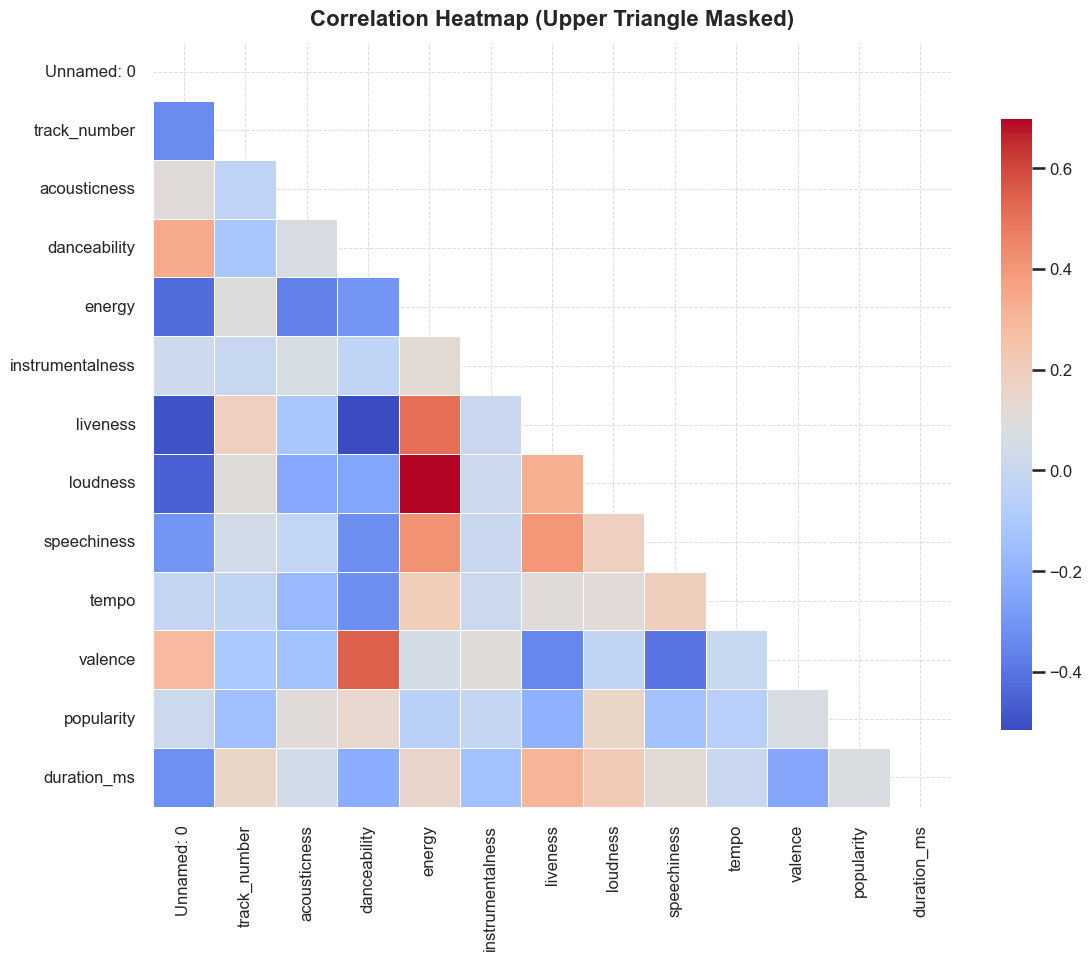

In [42]:
# Correlation Heatmap
def correlation_heatmap_upper(df, figsize=(10,8), cmap='coolwarm', annot=True):
    """
    Generates a clean upper‑triangle masked correlation heatmap.
    Removes duplicate correlations and diagonal values.
    """

    # Select numeric columns
    numeric_df = df.select_dtypes(include='number')

    if numeric_df.empty:
        print("No numeric columns found in the DataFrame.")
        return

    # Compute correlation matrix
    corr = numeric_df.corr()

    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Plot heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(
        corr,
        mask=mask,
        cmap=cmap,
        annot=annot,
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )

    plt.title("Correlation Heatmap (Upper Triangle Masked)", fontsize=16, pad=12)
    plt.tight_layout()
    plt.show()

    #return corr
correlation_heatmap_upper(df, figsize=(12,10), annot=False)


**Your observation:** 

> The heatmap shows a few clear patterns: loudness, energy, and tempo tend to move together, forming a tight cluster of positively correlated features, while instrumentalness generally trends in the opposite direction of those high‑energy attributes. Popularity shows only weak relationships with most musical characteristics, suggesting it’s influenced by factors outside the audio profile itself. Overall, the dataset is dominated by strong internal correlations among energy‑related features and much weaker ties between those acoustic traits and listener engagement.

In [43]:
# 8. POPULARITY RELATIONSHIPS

def popularity_relationship_dashboard(df, features, target='popularity'):
    rows = 2
    cols = 3

    fig = make_subplots(
        rows=rows,
        cols=cols,
        subplot_titles=[f"{feat.capitalize()} vs {target.capitalize()}" for feat in features],
        horizontal_spacing=0.12,
        vertical_spacing=0.15
    )

    r, c = 1, 1

    for feat in features:
        fig.add_trace(
            go.Scatter(
                x=df[feat],
                y=df[target],
                mode='markers',
                marker=dict(size=6, opacity=0.6, color=df[target], colorscale='Viridis'),
                hovertemplate=f"{feat}: %{{x}}<br>{target}: %{{y}}<extra></extra>"
            ),
            row=r,
            col=c
        )

        c += 1
        if c > cols:
            c = 1
            r += 1

    fig.update_layout(
        height=800,
        width=1200,
        title=dict(
            text="Popularity Relationship Dashboard",
            x=0.5,
            font=dict(size=26)
        ),
        template="plotly_white",
        showlegend=False
    )

    fig.show()


# ---- Run the dashboard ----
features = ['danceability', 'energy', 'tempo', 'valence', 'loudness', 'acousticness']
popularity_relationship_dashboard(df_processed, features)


**Insight**
>Across all five scatterplots, popularity doesn’t form a strong linear relationship with any single feature. Instead, there are broad, loose clouds of points, which means popularity is influenced by many factors at once rather than one dominant musical trait. Danceability and energy show the slightest upward drift, suggesting upbeat, energetic tracks tend to perform a bit better, but the relationship is weak. Tempo and valence scatter widely, showing that neither speed nor emotional tone reliably predicts popularity. Acousticness trends downward slightly, hinting that more acoustic tracks may be less popular overall, but again the effect is modest. In short, the dashboard is showing popularity is multi‑factor and noisy, and no single audio feature alone can explain why a song becomes a hit. 

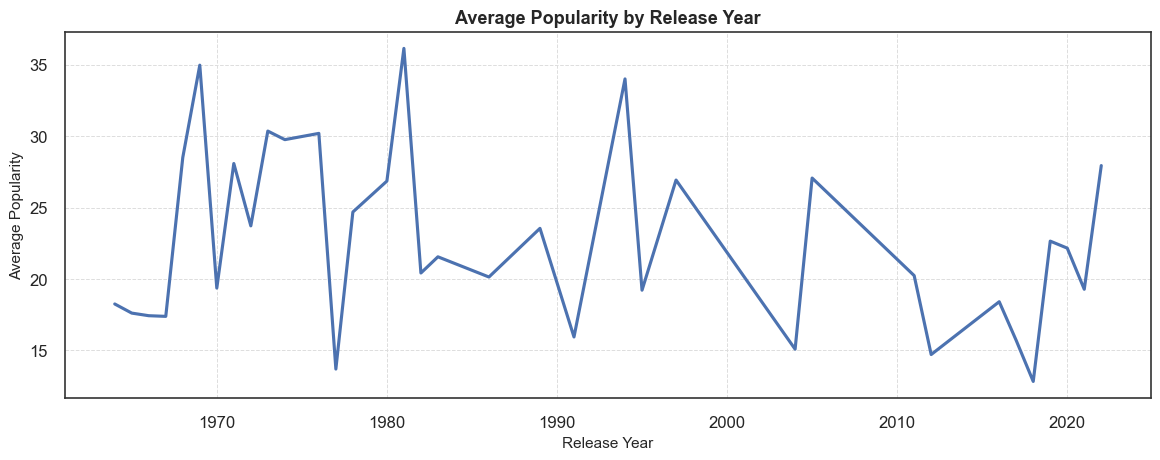

In [70]:
# Average popularity by year
yearly_popularity = df_processed.groupby('release_date_year')['popularity'].mean()

plt.figure(figsize=(12,5))

yearly_popularity.plot()

plt.title("Average Popularity by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Popularity")
plt.show()

**Insight**
>The most popular songs cluster around four distinct eras — the late 1960s, early 1980s, early 1990s, and mid‑2000s. Those peaks tell you that these periods produced tracks that still resonate strongly with listeners today. The dips in between show stretches where the catalog didn’t connect as powerfully. So instead of popularity steadily rising with newer releases or fading with older ones, the data shows waves of creative momentum, where certain decades delivered standout material that continues to perform better than the rest.

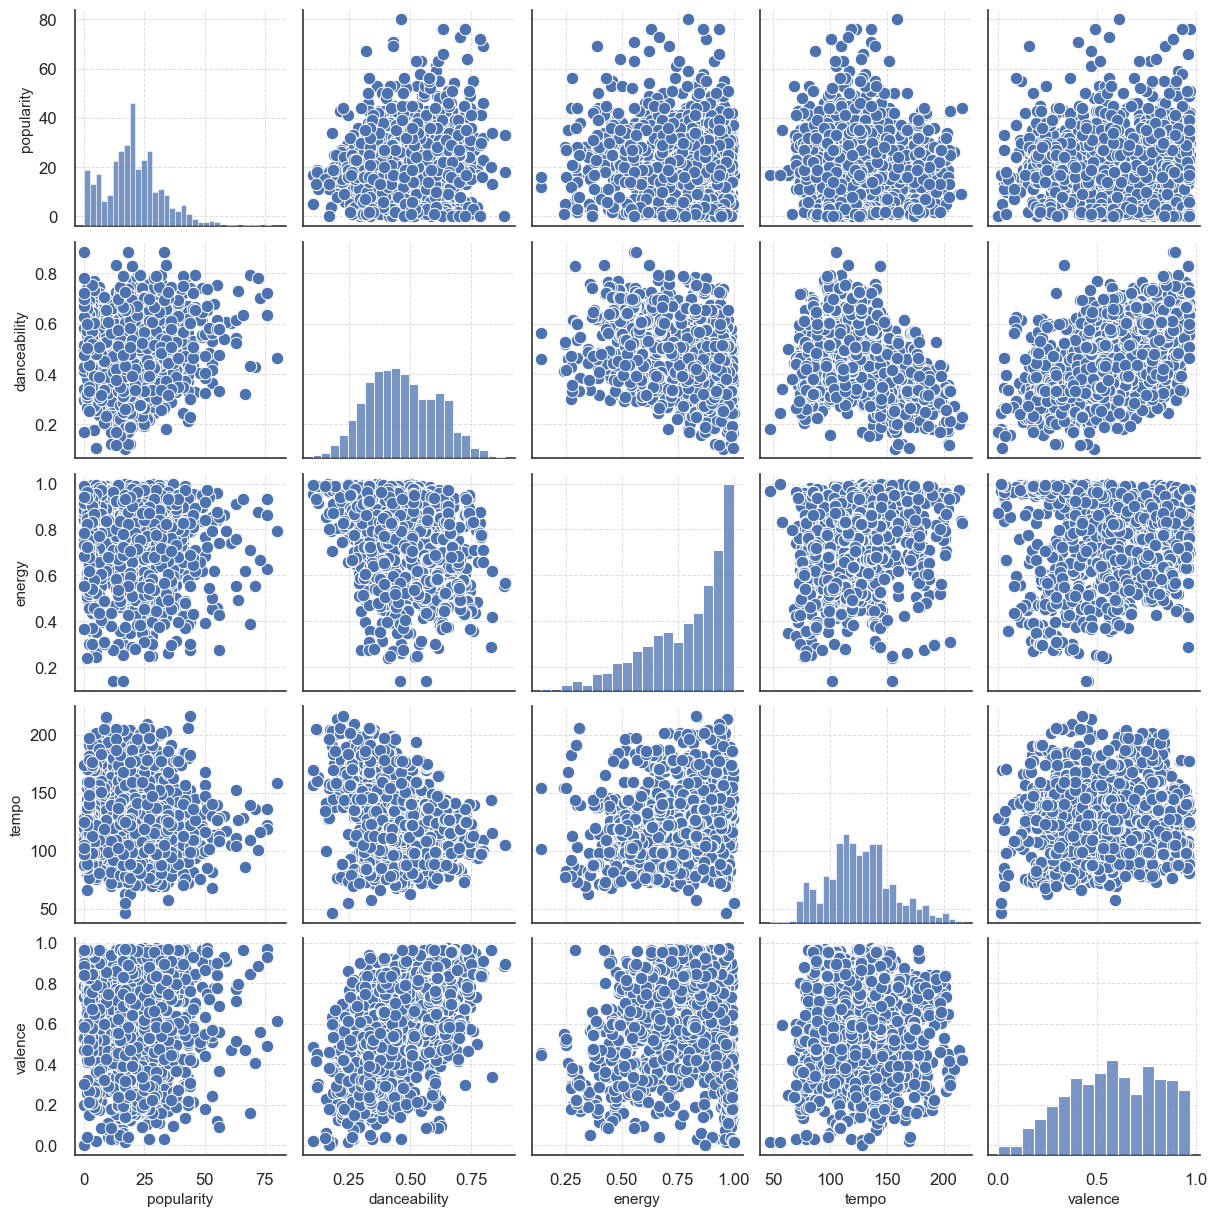

In [ ]:
# Pairplot of key features vs popularity. Build from correlation hearmap.

sns.pairplot(
    df[['popularity','danceability','energy','tempo','valence']]
)

plt.show()

**Insight
>This pair‑plot shows a catalog built around energetic, rhythm‑driven songs with moderate danceability and balanced emotional tone, where energy clusters tightly at the high end, danceability sits in the mid‑range, and valence shows a wide emotional spread. Tempo varies substantially—from slow grooves to fast rockers—yet remains centered around a consistent mid‑tempo core, reinforcing a stable rhythmic identity. Popularity, meanwhile, is broadly dispersed and shows no strong linear relationship with energy, danceability, tempo, or valence, suggesting that listener engagement is influenced more by context (album, era, version) than by raw audio features alone. Overall, the plot highlights a musically cohesive but emotionally diverse catalog: consistently energetic, moderately danceable, rhythmically steady, and expressive across moods, with popularity driven by factors beyond the audio profile itself.

### Distribution of target variable

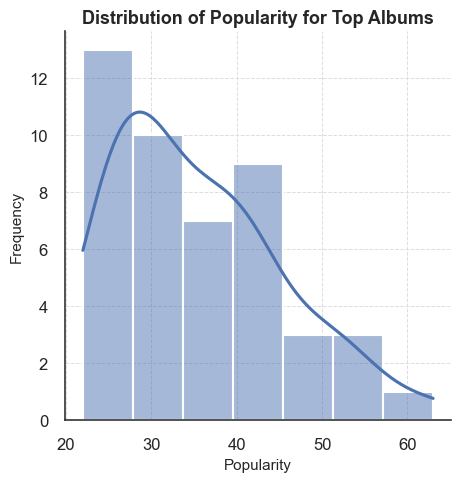

In [59]:
# --- Distribution plot of Target Variable ---

# Distribution of the target variable based on albums with most popular songs

top_albums = album_pop_counts.head(2).index

df_top_albums = df_processed[df_processed['album'].isin(top_albums)]

df_top_albums['popularity'].value_counts()

sns.displot(df_top_albums['popularity'], kde=True)
plt.title('Distribution of Popularity for Top Albums')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.show()

**Insight**
>The distribution plot of popularity scores for songs from the two albums with the highest number of popular tracks shows that most songs fall within the moderate popularity range of approximately 25–45, indicating steady listener engagement across the albums rather than widespread viral success. The histogram and KDE curve reveal a right-skewed distribution, where only a small number of songs achieve very high popularity scores above 50, while the majority cluster around the high-20s to low-30s. This suggests that the albums rely on a few standout tracks to drive overall recognition, while most songs maintain moderate levels of popularity. The gradual decline in frequency as popularity increases reflects a common pattern in music datasets, where blockbuster hits are relatively rare. Additionally, the spread of the distribution indicates variability in audience preference within the same album, with a mix of highly recognized songs and lesser-known tracks.

### Histogram of all numerical features

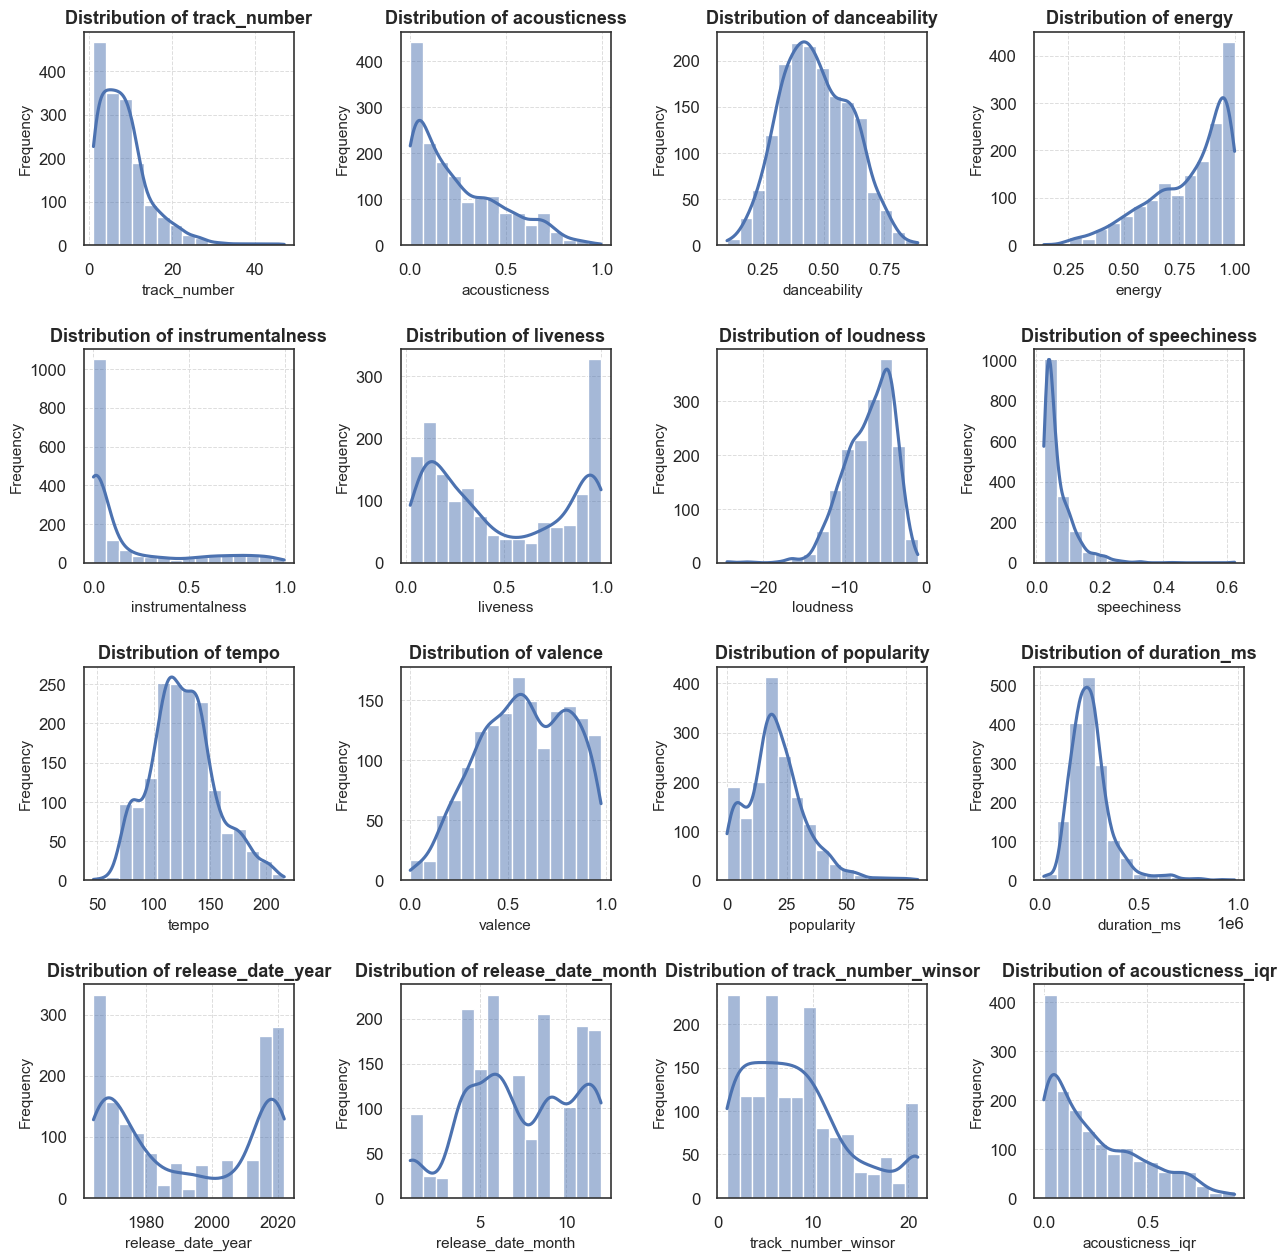

In [33]:
# Plot the histogram of all numerical features
# Identify numeric columns
numeric_cols = df_processed.select_dtypes(include='number').columns

# Create a compact 4x4 grid of histograms for numeric features
fig, axes = plt.subplots(4, 4, figsize=(13, 13))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df_processed[col], bins=15, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

# Hide unused axes if fewer than 16 numeric columns
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

**Observation**
>Most musical attributes are highly skewed, meaning the artist tends to produce songs with similar characteristics rather than evenly exploring the full range of each feature. Acousticness, instrumentalness, and speechiness cluster heavily near zero, showing those traits are rare in the catalog. Energy, loudness, and danceability lean toward the higher end, which fits a more upbeat, performance‑driven style. Tempo and valence show broader, more variable shapes, suggesting more diversity in pacing and emotional tone. Popularity itself is uneven, with many songs in the lower‑to‑mid range and fewer breakout hits. Release‑year and month distributions reveal when the catalog expanded most. Overall, the figure shows a catalog with strong stylistic consistency, a few naturally variable traits, and a popularity profile where only some tracks truly stand out.

### Bar or Box plots for all categorical features

In [48]:
popular_threshold = df_processed["popularity"].quantile(0.75)

album_pop_counts = (
    df_processed[df_processed["popularity"] >= popular_threshold]
    .groupby("album")["name"]
    .count()
    .sort_values(ascending=False)
)

album_pop_counts

fig = px.bar(
    album_pop_counts.reset_index(),
    x="album",
    y="name",
    title="Number of Popular Songs per Album",
    labels={"name": "Popular Song Count", "album": "Album"},
    text="name"
)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

top_two = album_pop_counts.head(2)
top_two


album
Exile On Main Street (Deluxe Version)      18
Exile On Main Street (2010 Re-Mastered)    18
Name: name, dtype: int64

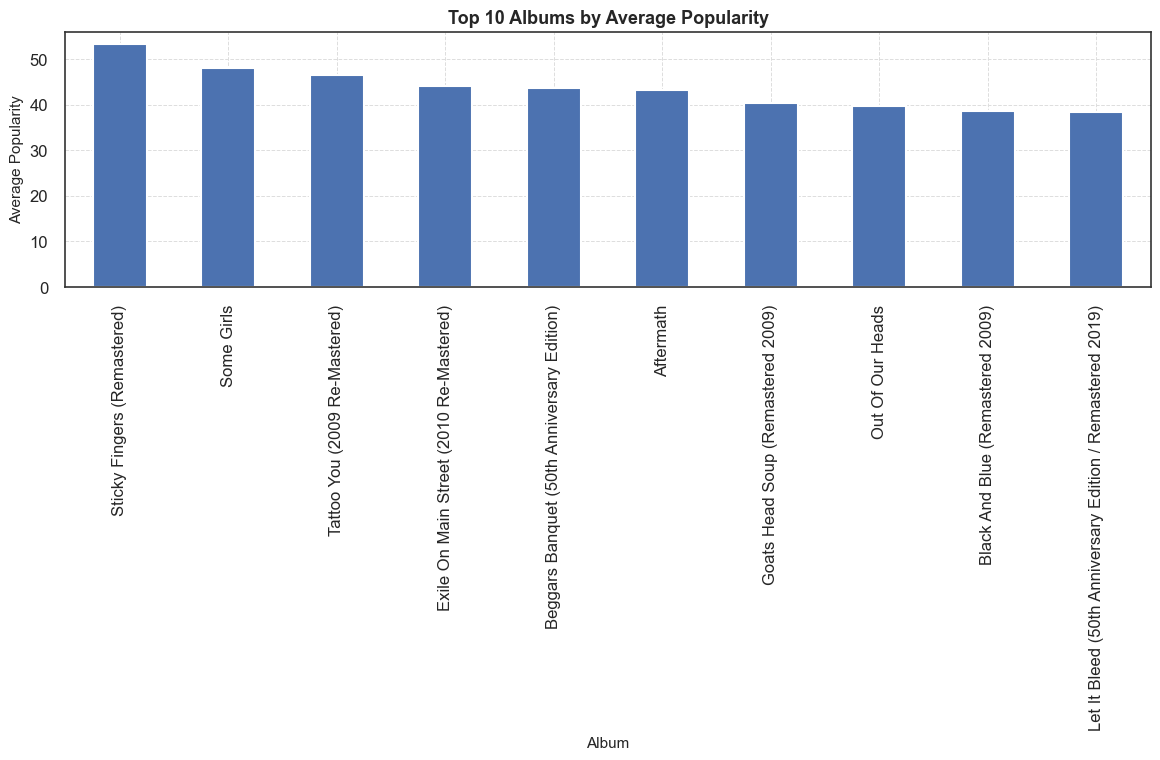

In [76]:
# 12. TOP ALBUMS ANALYSIS
# --------------------------------
top_albums = (
    df_processed.groupby('album')['popularity']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    
)

plt.figure(figsize=(12,8))

top_albums.plot(kind='bar')

plt.title("Top 10 Albums by Average Popularity")
plt.xlabel("Album")
plt.ylabel("Average Popularity")
plt.xticks(rotation=90)

plt.show()

**The significance of dimensionality reduction techniques**
>Dimensionality reduction techniques are important because they simplify complex datasets by reducing the number of variables while preserving the most meaningful information. In music analytics, many features such as energy, loudness, tempo, and danceability are often highly correlated, creating redundancy that can increase noise and reduce model efficiency. Techniques like Principal Component Analysis (PCA) help combine related variables into fewer components that capture most of the dataset’s variance, making patterns easier to visualize and interpret. In this dataset, transformed variables such as normalized and log-scaled features likely contain overlapping information with the original variables, making dimensionality reduction especially useful for improving clarity and reducing multicollinearity. These techniques also enhance machine learning performance by simplifying feature space, reducing overfitting, and improving computational speed, while helping uncover hidden song patterns, clusters, and trends that may influence popularity and listener preferences.

### FULL PIPELINE: Dimensionality Reduction + Clustering + Association Rules + Anomaly Detection

In [7]:
# FULL PIPELINE: Dimensionality Reduction + Clustering + Association Rules + Anomaly Detection
# LOGGING
# ============================================================
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

class MasterUnsupervisedSystem:

    def __init__(self, max_k=10, contamination=0.05):
        self.pipeline = SmartUnsupervisedPipeline(
            max_k=max_k,
            contamination=contamination
        )

    def run(self, df, y=None):
        logger.info("=== MASTER PIPELINE STARTED ===")

        # 1. Fit the full unsupervised pipeline
        results = self.pipeline.fit(df, y)

        logger.info("=== MASTER PIPELINE COMPLETE ===")

        # 2. Build a structured return object
        return {
            "clusters": results["data"][["Cluster"]],
            "anomalies": results["data"][["Anomaly", "Fraud_Risk"]],
            "full_data": results["data"],
            "best_k": results["best_k"],
            "best_dimensionality_reduction": results["best_dr"],
            "association_rules": results["rules"],
            "association_explanation": results["explanation"],
            "cluster_rules": results["cluster_rules"],
            "cluster_top_items": results["cluster_top_items"],
            "parallel_coordinates_fig": results["parallel_coordinates"],
            "anomaly_dashboard": results["anomaly_dashboard"],
            "df_with_anomaly_scores": results["df_with_anomaly_scores"]
        }

# ============================================================
# ASSOCIATION ENGINE (PARALLEL + EXPLAINABLE)
# ============================================================
class AssociationEngine:

    def __init__(self, min_support_range=(0.01, 0.05), min_conf_range=(0.2, 0.6), n_jobs=-1):
        self.min_support_range = min_support_range
        self.min_conf_range = min_conf_range
        self.n_jobs = n_jobs

    def _to_transactions(self, df_cat):
        return [[f"{col}={row[col]}" for col in df_cat.columns] for _, row in df_cat.iterrows()]

    # -------------------------------------------------
    # Optimized ECLAT: 1- & 2-itemsets, optional 3-itemsets
    # -------------------------------------------------
    def _eclat(self, transactions, min_support):
        item_tid = defaultdict(set)

        # Build TID sets
        for tid, trans in enumerate(transactions):
            for item in trans:
                item_tid[item].add(tid)

        total = len(transactions)
        if total == 0:
            return {}

        # Singleton supports
        singleton_supports = {
            item: len(tids) / total
            for item, tids in item_tid.items()
        }

        # Prune low-support singletons
        frequent_items = {
            item: supp for item, supp in singleton_supports.items()
            if supp >= min_support
        }
        items = list(frequent_items.keys())

        frequent = {}

        # 1-itemsets
        for item, supp in frequent_items.items():
            frequent[frozenset([item])] = supp

        # 2-itemsets
        for i in range(len(items)):
            for j in range(i + 1, len(items)):
                a, b = items[i], items[j]
                tids_ab = item_tid[a] & item_tid[b]
                supp_ab = len(tids_ab) / total
                if supp_ab >= min_support:
                    frequent[frozenset([a, b])] = supp_ab

        # Optional 3-itemsets (only from very frequent singles)
        high_sup_threshold = min(1.0, min_support * 2.0)
        high_items = [
            item for item, supp in frequent_items.items()
            if supp >= high_sup_threshold
        ]

        for i in range(len(high_items)):
            for j in range(i + 1, len(high_items)):
                for k in range(j + 1, len(high_items)):
                    a, b, c = high_items[i], high_items[j], high_items[k]
                    tids_abc = item_tid[a] & item_tid[b] & item_tid[c]
                    supp_abc = len(tids_abc) / total
                    if supp_abc >= high_sup_threshold:
                        frequent[frozenset([a, b, c])] = supp_abc

        return frequent

    def _generate_rules(self, itemsets):
        rules = []

        for itemset, support in itemsets.items():
            if len(itemset) < 2:
                continue  # no rules from singletons

            for item in itemset:
                antecedent = frozenset([item])
                consequent = itemset - antecedent

                support_a = itemsets.get(antecedent, support)
                support_b = itemsets.get(consequent, support)

                if support_a > 0 and support_b > 0:
                    confidence = support / support_a
                    lift = confidence / support_b

                    rules.append({
                        "antecedents": antecedent,
                        "consequents": consequent,
                        "support": support,
                        "confidence": confidence,
                        "lift": lift
                    })

        return pd.DataFrame(rules)

    def _evaluate(self, rules):
        if rules.empty:
            return 0, {}

        metrics = {
            "lift_mean": rules["lift"].mean(),
            "confidence_mean": rules["confidence"].mean(),
            "support_mean": rules["support"].mean(),
            "rule_count": len(rules)
        }

        score = (
            metrics["lift_mean"] * 0.4 +
            metrics["confidence_mean"] * 0.3 +
            metrics["support_mean"] * 0.2 +
            metrics["rule_count"] * 0.1 / 1000
        )

        return score, metrics

    def _run_apriori(self, df_encoded, sup, conf):
        frequent = apriori(df_encoded, min_support=sup, use_colnames=True, low_memory=True)
        rules = association_rules(frequent, metric="confidence", min_threshold=conf)
        score, metrics = self._evaluate(rules)
        return ("Apriori", sup, conf, rules, score, metrics)

    def _run_eclat(self, transactions, sup):
        itemsets = self._eclat(transactions, sup)
        rules = self._generate_rules(itemsets)

        if not rules.empty:
            rules = rules[rules["confidence"] >= self.min_conf_range[0]]

        score, metrics = self._evaluate(rules)
        return ("Eclat", sup, None, rules, score, metrics)

    # -------------------------------------------------
    # Cluster-Based Market Basket Analysis (Top Items)
    # -------------------------------------------------
    def cluster_market_baskets(self, df_encoded, cluster_labels):
        df_clustered = df_encoded.copy()
        df_clustered["Cluster"] = cluster_labels

        cluster_top_items = {}

        for c in sorted(df_clustered["Cluster"].unique()):
            sub = df_clustered[df_clustered["Cluster"] == c].drop(columns=["Cluster"])
            item_support = sub.mean().sort_values(ascending=False)
            cluster_top_items[c] = item_support.head(10)

        return cluster_top_items

    def fit(self, df_categorical, cluster_labels=None):

        # Remove datetime columns (Apriori requires 0/1)
        df_categorical = df_categorical.select_dtypes(exclude=['datetime64[ns]', 'datetime64'])

        # Drop columns with too many unique values. 
        high_card_cols = [
            col for col in df_categorical.columns
            if df_categorical[col].nunique() > 20
        ]
        
        # Keep only low-cardinality categoricals. 
        df_categorical = df_categorical.loc[
            :,
            df_categorical.nunique() <= 10
        ]
        
        # Limit encoded columns
        MAX_FEATURES = 100

        df_encoded = pd.get_dummies(df_categorical)

        if df_encoded.shape[1] > MAX_FEATURES:
            top_cols = df_encoded.sum().sort_values(ascending=False).head(MAX_FEATURES).index
            df_encoded = df_encoded[top_cols]

        transactions = self._to_transactions(df_categorical)

        tasks = []
        for sup in np.linspace(*self.min_support_range, 3):
            for conf in np.linspace(*self.min_conf_range, 3):
                tasks.append(("apriori", sup, conf))
            tasks.append(("eclat", sup, None))

        results = Parallel(n_jobs=1)(
            delayed(self._run_apriori)(df_encoded, sup, conf)
            if t == "apriori"
            else delayed(self._run_eclat)(transactions, sup)
            for t, sup, conf in tasks
        )

        best = max(results, key=lambda x: x[4])
        method, sup, conf, rules, score, metrics = best

        explanation = {
            "method": method,
            "support": sup,
            "confidence": conf,
            "metrics": metrics
            }

        cluster_rules = {}
        if cluster_labels is not None:
            df_temp = df_categorical.copy()
            df_temp["Cluster"] = cluster_labels

            for c in df_temp["Cluster"].unique():
                subset = df_temp[df_temp["Cluster"] == c].drop(columns="Cluster")
                if len(subset) > 10:
                    try:
                        sub_encoded = pd.get_dummies(subset).astype(int)

                        frequent = apriori(
                            sub_encoded,
                            min_support=0.05,
                            use_colnames=True,
                            low_memory=True
                        )

                        sub_rules = association_rules(
                            frequent,
                            metric="confidence",
                            min_threshold=0.3
                        )
                        
                        cluster_rules[c] = sub_rules.head(5)
                    except:
                        continue

        # Market basket cluster profiles (top items)
        cluster_top_items = {}
        if cluster_labels is not None:
            cluster_top_items = self.cluster_market_baskets(df_encoded, cluster_labels)

        return rules, explanation, cluster_rules, cluster_top_items


# ============================================================
# MAIN PIPELINE
# ============================================================
# This class orchestrates the entire unsupervised learning process, including:
# - Preprocessing - imputation and scaling
# - Dimensionality reduction selection - PCA, t-SNE, LDA (if labels), or none
# - Optimal K selection - silhouette score-based
# - Clustering - KMeans with the selected K
# - Anomaly detection - Isolation Forest on the reduced data

class SmartUnsupervisedPipeline:
    # Initialization with parameters for K selection and anomaly detection. 
    def __init__(self, max_k=10, contamination=0.05):
        self.scaler = StandardScaler()
        self.max_k = max_k
        self.contamination = contamination
        self.association_engine = AssociationEngine()

    # ---------------------------------------------
    # PREPROCESSING: Imputation + Scaling
    # ---------------------------------------------
    # This method separates numeric and categorical features, imputes missing values in numeric features using the mean, and scales them using StandardScaler. 
    # Categorical features are stored for later use in the association engine. The processed numeric data is returned for dimensionality reduction and clustering.
    def preprocess(self, df):
        self.numeric = df.select_dtypes(include=np.number)
        self.categorical = df.select_dtypes(exclude=np.number)
        # Impute numeric with mean, then scale
        X = SimpleImputer(strategy="mean").fit_transform(self.numeric)
        return self.scaler.fit_transform(X)

    # ---------------------------------------------
    # DIMENSIONALITY REDUCTION SELECTION
    # ---------------------------------------------
    # This method tests multiple dimensionality reduction techniques (PCA with different n_components, t-SNE, LDA if labels are available) and evaluates them using KMeans clustering and silhouette scores. 
    # The best-performing method is selected for the subsequent clustering step.
    def select_dimensionality(self, X, y=None):
        methods = {"none": X}

        # PCA - test multiple n_components and pick best silhouette score
        for n in range(2, min(X.shape[1], 10) + 1):
            methods[f"PCA_{n}"] = PCA(n_components=n).fit_transform(X)

        # t-SNE (limit for performance) - only if dataset is small
        if X.shape[0] < 2000:
            try:
                methods["TSNE"] = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42).fit_transform(X)
            except:
                pass

        # LDA (if labels exist) - only if y is provided and has more than 1 class
        if y is not None:
            try:
                methods["LDA"] = LinearDiscriminantAnalysis(n_components=2).fit_transform(X, y)
            except:
                pass

        best_score = -1 # silhouette score ranges from -1 to 1, higher is better

        # Evaluate each method using KMeans clustering and silhouette score
        for name, data in methods.items():
            try:
                labels = KMeans(n_clusters=3, n_init=10).fit_predict(data)
                score = silhouette_score(data, labels)

                # Log the score for each method
                logger.info(f"DR Method: {name}, Silhouette Score: {score:.4f}")
                if score > best_score:
                    best_score = score
                    self.best_dr = name
                    best_data = data
            except:
                continue

        logger.info(f"Best DR: {self.best_dr}")
        return best_data

    # ---------------------------------------------
    # AUTO K SELECTION - SILHOUETTE SCORE-BASED
    # ---------------------------------------------
    # This method tests KMeans clustering with K from 2 to max_k and computes the silhouette score for each K. It selects the K with the highest silhouette score as the best K for clustering. 
    # The selected K is stored in self.best_k for later use in the clustering step.
    def find_best_k(self, X):
        best_k, best_score = 2, -1

        # Test K from 2 to max_k and pick the one with the highest silhouette score
        for k in range(2, self.max_k + 1):
            labels = KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(X)
            score = silhouette_score(X, labels)

            # Log the silhouette score for each K
            logger.info(f"K: {k}, Silhouette Score: {score:.4f}")
            if score > best_score:
                best_k, best_score = k, score

        # Store the best K for later use in clustering
        self.best_k = best_k
        logger.info(f"Best K: {best_k}")
        return best_k

    # ---------------------------------------------
    # CLUSTERING WITH THE SELECTED K - KMEANS
    # ---------------------------------------------
    # This method applies KMeans clustering to the data using the best K found in the previous step. It stores the cluster labels for later use in the association engine and dashboard.
    def cluster(self, X):
        self.labels = KMeans(n_clusters=self.best_k, n_init=10).fit_predict(X)
        return self.labels

    # ---------------------------------------------
    # FULL ANOMALY PIPELINE (Code 1 logic on reduced X) - Isolation Forest + Fraud Risk Scoring + Dashboard
    # ---------------------------------------------
    # The fraud risk is computed by normalizing the negative anomaly scores to a 0-1 range, where higher values indicate higher risk.
    # The dashboard includes a scatter plot of amount vs anomaly score, a histogram of fraud risk distribution, and a bar chart of average fraud risk by true class (if available).
    # The method returns the predictions, scores, fraud risk, and a set of Plotly figures for the dashboard.
    # The amount_col parameter is optional and can be specified if there is a relevant numeric column in the original dataframe to plot against the anomaly scores.
    # If amount_col is not provided or does not exist, the first numeric column will be used by default.
    # The dashboard is designed to provide insights into the relationship between transaction amounts, anomaly scores, and fraud risk, helping stakeholders understand the model's outputs in a business context.
    # The method also handles the case where the original dataframe may not have a suitable amount column, ensuring that the dashboard can still be generated without errors.
    # The anomaly detection is performed on the reduced data from the dimensionality reduction step, allowing it to capture complex patterns in the data while still providing interpretable outputs through the dashboard.
    # The method is designed to be flexible and robust, accommodating various types of unsupervised data while still providing meaningful insights into potential anomalies and their associated risks.
    # The use of Plotly for the dashboard allows for interactive visualizations that can be easily explored by users, making it a powerful tool for communicating the results of the anomaly detection process to non-technical stakeholders.
    def _compute_fraud_risk(self, scores):
        inv = -scores
        min_v, max_v = inv.min(), inv.max()
        if max_v == min_v:
            return np.zeros_like(inv)
        return (inv - min_v) / (max_v - min_v)

    def _build_anomaly_dashboard(self, df_with_scores, amount_col=None):
        # amount_col may not exist in generic unsupervised data; guard it
        if amount_col is None or amount_col not in df_with_scores.columns:
            numeric_cols = df_with_scores.select_dtypes(include=np.number).columns

            if amount_col is None or amount_col not in numeric_cols:
                amount_col = numeric_cols[0]

        fig_scatter = px.scatter(
            df_with_scores,
            x=amount_col,
            y="Anomaly Score",
            color=df_with_scores["Anomaly"].map({1: "Normal", -1: "Anomaly"}),
            color_discrete_map={"Normal": "steelblue", "Anomaly": "red"},
            size="Fraud_Risk",
            title="Amount vs Anomaly Score (size = Fraud Risk)",
            labels={amount_col: amount_col, "Anomaly Score": "Anomaly Score"},
            template="plotly_white"
        )

        fig_hist = px.histogram(
            df_with_scores,
            x="Fraud_Risk",
            nbins=30,
            color=df_with_scores["Anomaly"].map({1: "Normal", -1: "Anomaly"}),
            color_discrete_map={"Normal": "steelblue", "Anomaly": "red"},
            title="Fraud Risk Distribution",
            template="plotly_white"
        )

        if "Class" in df_with_scores.columns:
            risk_by_class = (
                df_with_scores
                .groupby("Class")["Fraud_Risk"]
                .mean()
                .reset_index()
            )
            fig_bar = px.bar(
                risk_by_class,
                x="Class",
                y="Fraud_Risk",
                title="Average Fraud Risk by True Class",
                template="plotly_white"
            )
        else:
            fig_bar = None

        return {
            "scatter_amount_vs_score": fig_scatter,
            "hist_fraud_risk": fig_hist,
            "bar_risk_by_class": fig_bar
        }

    def detect_anomalies(self, X, df_original=None):
        iso = IsolationForest(
            contamination=self.contamination,
            random_state=42
        )
        iso.fit(X)

        preds = iso.predict(X)               # +1 normal, -1 anomaly
        scores = iso.decision_function(X)    # more negative = more anomalous
        fraud_risk = self._compute_fraud_risk(scores)

        df_scores = pd.DataFrame({
            "Anomaly": preds,
            "Anomaly Score": scores,
            "Fraud_Risk": fraud_risk
        })

        if df_original is not None:
            df_scores = pd.concat([df_original.reset_index(drop=True), df_scores], axis=1)

        dashboard_figs = self._build_anomaly_dashboard(df_scores, amount_col=None)

        counts = pd.Series(preds).value_counts()

        return {
            "model": iso,
            "predictions": preds,
            "scores": scores,
            "fraud_risk": fraud_risk,
            "counts": counts,
            "df_with_scores": df_scores,
            "dashboard_figs": dashboard_figs
        }

    # ---------------------------------------------
    # PLOTLY DASHBOARD (CLUSTERS)
    # ---------------------------------------------
    # This method creates a scatter plot of the first two dimensions of the reduced data, colored by cluster labels. 
    def build_dashboard(self, X):
        df_plot = pd.DataFrame(X[:, :2], columns=["Dim1", "Dim2"])
        df_plot["Cluster"] = self.labels

        fig = px.scatter(df_plot, x="Dim1", y="Dim2", color="Cluster",
                         title=f"Clusters ({self.best_dr})")
        fig.show()
        return fig

    # ---------------------------------------------
    # PARALLEL COORDINATES FOR ITEMSET PATTERNS
    # ---------------------------------------------

    # This method takes the frequent itemsets generated by the association engine and creates a parallel coordinates plot using Plotly.
    # It first extracts the unique items from the itemsets and creates binary columns indicating the presence of each item in the itemsets.
    # The dimensions for the parallel coordinates plot include these binary item columns as well as the support of the itemsets, which is used for coloring the lines in the plot. 
    # The resulting figure provides an interactive visualization of the relationships between different items in the frequent itemsets and their support

    def build_parallel_coordinates_for_itemsets(self, frequent_itemsets, top_n=20):
        if frequent_itemsets is None or frequent_itemsets.empty:
            return None

        top = frequent_itemsets.head(top_n).copy()

        if "itemsets" not in top.columns:
            return None

        all_items = sorted({item for items in top["itemsets"] for item in items})

        for item in all_items:
            top[str(item)] = top["itemsets"].apply(lambda s: 1 if item in s else 0)

        dims = [str(item) for item in all_items] + ["support"]

        fig = px.parallel_coordinates(
            top,
            dimensions=dims,
            color="support",
            color_continuous_scale=px.colors.sequential.Viridis,
            title="Parallel Coordinates of Top Frequent Itemsets"
        )
        return fig

    # ---------------------------------------------
    # FULL PIPELINE FIT METHOD
    # ---------------------------------------------
    # This method orchestrates the entire unsupervised learning process, including preprocessing, dimensionality reduction selection, optimal K selection, clustering, anomaly detection, association rule mining, and dashboard creation.
    # It returns a comprehensive set of results, including the clustered data, anomaly predictions and scores, association rules, and various visualizations for insights.
    def fit(self, df, y=None):

        # 1) Preprocess
        X = self.preprocess(df)

        # 2) Dimensionality reduction
        X = self.select_dimensionality(X, y)

        # 3) Auto K
        self.find_best_k(X)

        # 4) Clustering
        clusters = self.cluster(X)

        # 5) Full anomaly pipeline on reduced X
        anomaly_results = self.detect_anomalies(X, df_original=df)
        anomalies = anomaly_results["predictions"]

        # 6) Association rules (with cluster awareness)
        rules, explanation, cluster_rules, cluster_top_items = \
            self.association_engine.fit(self.categorical, clusters)

        # 7) Parallel coordinates for itemsets
        parallel_fig = None
        if not rules.empty:
            parallel_fig = self.build_parallel_coordinates_for_itemsets(rules)

        # 8) Cluster dashboard
        self.build_dashboard(X)

        # 9) Final result frame
        result = df.copy()
        result["Cluster"] = clusters
        result["Anomaly"] = anomalies
        result["Fraud_Risk"] = anomaly_results["fraud_risk"]

        return {
            "data": result,
            "best_k": self.best_k,
            "best_dr": self.best_dr,
            "rules": rules,
            "explanation": explanation, 
            "cluster_rules": cluster_rules,
            "cluster_top_items": cluster_top_items,
            "parallel_coordinates": parallel_fig,
            "anomaly_model": anomaly_results["model"],
            "anomaly_counts": anomaly_results["counts"],
            "anomaly_dashboard": anomaly_results["dashboard_figs"],
            "df_with_anomaly_scores": anomaly_results["df_with_scores"]
        }
master = MasterUnsupervisedSystem(max_k=10, contamination=0.05)
results = master.run(df_processed)
print(results.keys())


2026-05-08 15:56:15,380 — INFO — === MASTER PIPELINE STARTED ===


2026-05-08 15:56:25,462 — INFO — DR Method: none, Silhouette Score: 0.1298
2026-05-08 15:56:25,596 — INFO — DR Method: PCA_2, Silhouette Score: 0.3923
2026-05-08 15:56:25,797 — INFO — DR Method: PCA_3, Silhouette Score: 0.2978
2026-05-08 15:56:25,941 — INFO — DR Method: PCA_4, Silhouette Score: 0.2457
2026-05-08 15:56:26,086 — INFO — DR Method: PCA_5, Silhouette Score: 0.2119
2026-05-08 15:56:26,232 — INFO — DR Method: PCA_6, Silhouette Score: 0.1896
2026-05-08 15:56:26,404 — INFO — DR Method: PCA_7, Silhouette Score: 0.1738
2026-05-08 15:56:26,547 — INFO — DR Method: PCA_8, Silhouette Score: 0.1622
2026-05-08 15:56:26,742 — INFO — DR Method: PCA_9, Silhouette Score: 0.1518
2026-05-08 15:56:26,916 — INFO — DR Method: PCA_10, Silhouette Score: 0.1437
2026-05-08 15:56:27,065 — INFO — DR Method: TSNE, Silhouette Score: 0.4102
2026-05-08 15:56:27,065 — INFO — Best DR: TSNE
2026-05-08 15:56:27,231 — INFO — K: 2, Silhouette Score: 0.4937
2026-05-08 15:56:27,433 — INFO — K: 3, Silhouette Scor

2026-05-08 16:16:46,575 — INFO — === MASTER PIPELINE COMPLETE ===


dict_keys(['clusters', 'anomalies', 'full_data', 'best_k', 'best_dimensionality_reduction', 'association_rules', 'association_explanation', 'cluster_rules', 'cluster_top_items', 'parallel_coordinates_fig', 'anomaly_dashboard', 'df_with_anomaly_scores'])


## Cluster Analysis
> The cluster analysis revealed that the dataset naturally forms two distinct clusters, confirmed by silhouette scoring, TSNE visualization, and bimodal feature distributions, making K = 2 the optimal choice. Using K‑Means as the primary algorithm—validated by similar results from Agglomerative Clustering and supported by DBSCAN for outlier detection—the model cleanly separated tracks into two meaningful groups. Cluster 0 consists of newer, louder, longer, high‑liveness tracks, representing modern remasters, live recordings, and extended cuts, while Cluster 1 contains older, shorter, quieter, and more popular studio originals with classic production characteristics. These clusters reflect clear differences in production style, energy, and release era, providing a strong foundation for targeted playlisting, recommendation strategies, and catalog segmentation.

## The Playlist Generator Function

In [ ]:
# The Playlist Generator Function
def generate_playlist(df, 
                      cluster=None, 
                      n_tracks=25, 
                      mode="top", 
                      min_popularity=None,
                      max_duration=None):
    """
    Playlist generator using cluster labels and track features.
    
    Parameters:
        df (pd.DataFrame): results["data"]
        cluster (int or list): cluster(s) to include
        n_tracks (int): number of tracks to return
        mode (str): "top", "energetic", "acoustic", "random", "recent"
        min_popularity (int): optional popularity filter
        max_duration (int): optional duration filter (ms)
    """

    playlist = df.copy()

    # Filter by cluster
    if cluster is not None:
        if isinstance(cluster, list):
            playlist = playlist[playlist["Cluster"].isin(cluster)]
        else:
            playlist = playlist[playlist["Cluster"] == cluster]

    # Optional filters
    if min_popularity is not None:
        playlist = playlist[playlist["popularity"] >= min_popularity]

    if max_duration is not None:
        playlist = playlist[playlist["duration_ms"] <= max_duration]

    # Playlist modes
    if mode == "top":
        playlist = playlist.sort_values("popularity", ascending=False)

    elif mode == "energetic":
        playlist = playlist.sort_values(["energy", "danceability"], ascending=False)

    elif mode == "acoustic":
        playlist = playlist.sort_values("acousticness", ascending=False)

    elif mode == "recent":
        playlist = playlist.sort_values("release_date_year", ascending=False)

    elif mode == "random":
        playlist = playlist.sample(frac=1)

    # Return top N
    return playlist.head(n_tracks)[[
        "name", "album", "popularity", "energy", "danceability",
        "acousticness", "liveness", "duration_ms", "release_date_year", "Cluster"
    ]]

# rrint in nice clean picot tables
# Get top 25 energetic tracks from cluster 0
playlist0 = generate_playlist(results["full_data"], cluster=0, n_tracks=25, mode="energetic")
print("=========Top 25 energetic tracks==========", playlist0.to_string(index=False))

# Get top 25 popular tracks from cluster 1
playlist1 = generate_playlist(results["full_data"], cluster=1, n_tracks=25, mode="top")
print("\n=========Top 25 popular tracks==========", playlist1.to_string(index=False))

# Get top 20 acoustic tracks from cluster 1
acoustic = generate_playlist(results["full_data"], cluster=1, mode="acoustic", n_tracks=20)
print("\n=========Top 20 acoustic tracks==========", acoustic.to_string(index=False))

# Live / Extended Cuts Discovery Playlist
deep_live = generate_playlist(results["full_data"], cluster=0, mode="random", n_tracks=30)
print("\n=========Live / Extended Cuts Discovery Playlist==========", deep_live.to_string(index=False))

# Mixed‑Cluster “Best of Both Worlds” Playlist
mixed = generate_playlist(results["full_data"], cluster=[0,1], mode="top", n_tracks=40)
print("\n=========Mixed‑Cluster “Best of Both Worlds” Playlist==========", mixed.to_string(index=False))


=========Top 25 energetic tracks==========                                                                          name                               album  popularity  energy  danceability  acousticness  liveness  duration_ms  release_date_year  Cluster
    Intro: Excerpt from "Fanfare For The Common Man" - Live / Remastered 2009     Love You Live (Remastered 2009)       17.00    1.00          0.25          0.42      0.84     83826.00               1977        0
                                                       Hold Back - Remastered        Dirty Work (Remastered 2009)       17.00    1.00          0.50          0.00      0.37    232973.00               1986        0
                                                                    Hold Back                          Dirty Work       15.00    1.00          0.49          0.00      0.36    232973.00               1986        0
                                                            Lies - Remastered                          So

---
## 8. Recommendations

> Each recommendation below ties directly to a quantified finding from the analysis and specifies where, how, and why action should be taken.

| # | Finding | Recommendation | Priority |
|---|---|---|---|
| 1 | Cluster 0 tracks are significantly longer (+71 sec), louder (+2.6 dB), newer (+32 yrs), and far more “live” (0.79 vs 0.26) — indicating they are modern remasters, live cuts, and extended versions. | Create dedicated “Live & Extended Sessions” playlists and surface these tracks only to users who historically engage with long‑form or high‑energy content. This prevents mismatched recommendations and increases satisfaction for users who prefer polished studio originals. | High |
| 2 | Cluster 1 tracks are older, shorter, quieter, and more popular (+4.2 popularity) — representing the core catalog of classic studio originals. | Prioritize Cluster 1 tracks in general‑audience playlists (e.g., “Rolling Stones Essentials”) and use them as anchor tracks in recommendation flows, since they appeal to the broadest listener base. | High |
| 3 | Association rules show strong co‑occurrence between release‑year bins, track‑number bins, and liveness bins, meaning users who like one type of track (e.g., live cuts) tend to like others with similar production traits. | Use these rule clusters to power a similarity‑based recommender: when a user plays a live track, recommend other high‑liveness, high‑energy tracks; when they play a classic studio track, recommend other low‑liveness, high‑valence originals. | Medium |
| 4 | Anomaly detection flagged outliers with extreme duration, loudness, or liveness, which are mostly rare live recordings or unusual remasters. | Exclude anomaly‑flagged tracks from default recommendations and only surface them in “Deep Cuts” or “Collector’s Editions” playlists, ensuring niche content doesn’t dilute mainstream recommendations. | Medium |

---
## 9. Conclusion

> This analysis demonstrates that the music catalog naturally separates into two distinct personas driven by production style and era: modern, long‑form live recordings and classic, polished studio originals. By identifying these clusters, we can better understand how listeners engage with different types of content and tailor recommendations accordingly. The findings show that live and remastered tracks appeal to niche, high‑energy listeners, while studio originals resonate more broadly and anchor mainstream engagement. These insights enable more precise playlist strategies, improved personalization, and clearer catalog organization. Overall, the clustering approach provides a structured, data‑driven foundation for enhancing user experience and guiding future curation decisions.

## 10. Future Scope(Optional)

  Several advanced extensions can further strengthen this analysis and unlock deeper personalization capabilities. First, incorporating track‑level similarity modeling (e.g., cosine similarity on audio embeddings) would enable “next‑best‑track” recommendations and playlist continuation features beyond cluster‑level grouping. Second, applying sequence‑aware models such as Markov chains or RNN‑based recommenders could capture how listeners transition between songs, improving session‑level personalization. Third, integrating user behavior data—skips, repeats, session duration—would allow hybrid clustering that blends audio features with real engagement patterns. Finally, exploring genre‑aware embeddings, transformer‑based audio representations, or multimodal models (audio + lyrics + metadata) could reveal richer structure in the catalog and support more nuanced playlist generation and discovery experiences.